# **Bank Customer Churn Prediction**
End-to-End Machine Learning predicting bank customers are likely to churn(close their account), from a raw CSV of 10,000 customers through cleaning, EDA, feature engineering, model training and comparison, to a reuseable predicition pipeline.

**Structure**
1. Data Cleaning
2. EDA & Visualization
3. Feature Engineering
4. Model Training (split → encode → scale → train → evaluate → compare → save)
5. Prediction Pipeline


In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
%matplotlib inline

RANDOM_STATE = 42

: 

### 1. Data Cleaning

In [ ]:
# load dataset
df = pd.read_csv("data/Bank Customer Churn Prediction.csv")

print("Raw Shape", df.shape)
df.head()

In [ ]:
df.info()

## Churn
- 0 -> Retained
- 1 -> Churn

In [ ]:
# Missing Values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() else "None found.")

In [ ]:
# Duplicate rows / duplicate customers
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer_id:", df["customer_id"].duplicated().sum())

In [ ]:
# Value range of numeric features
df[["credit_score", "age", "tenure", "balance", "products_number", "estimated_salary"]].describe()

In [ ]:
# customer_id is a unique identifier with no predictive signal, drop it,
# but keep a copy in case it need to trace a prediction back to a customer
customer_ids = df["customer_id"].copy
df_clean = df.drop(columns = ["customer_id"]).copy()

# standardize categorical text
for col in ["country", "gender"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print(f"Column before drop -> shape: {df.shape}")
print(f"Column after drop -> shape: {df_clean.shape}")

df_clean.head()

In [ ]:
print(df_clean["churn"].value_counts())
print(df_clean["churn"].value_counts(normalize = True).round(2))

In [ ]:
# Project folder structure 

PROJECT_ROOT = Path.cwd()

CLEAN_DIR   = PROJECT_ROOT / "clean_data"
CHARTS_DIR  = PROJECT_ROOT / "charts"
MODELS_DIR  = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
SCRIPT_DIR  = PROJECT_ROOT / "script"

for d in [CLEAN_DIR, CHARTS_DIR, MODELS_DIR, REPORTS_DIR, SCRIPT_DIR]:
    d.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
for d in [CLEAN_DIR, CHARTS_DIR, MODELS_DIR, REPORTS_DIR, SCRIPT_DIR]:
    print(" -", d.name + "/")

In [ ]:
df_clean.to_csv(CLEAN_DIR / "cleaned_customer_churn.csv", index=False)
print("Saved cleaned dataset to", CLEAN_DIR / "cleaned_customer_churn.csv")
print("Shape:", df_clean.shape)

# **EDA AND VISUALIZATION**

In [11]:
def savefig(name):
    plt.savefig(CHARTS_DIR / name, dpi=300, bbox_inches="tight")

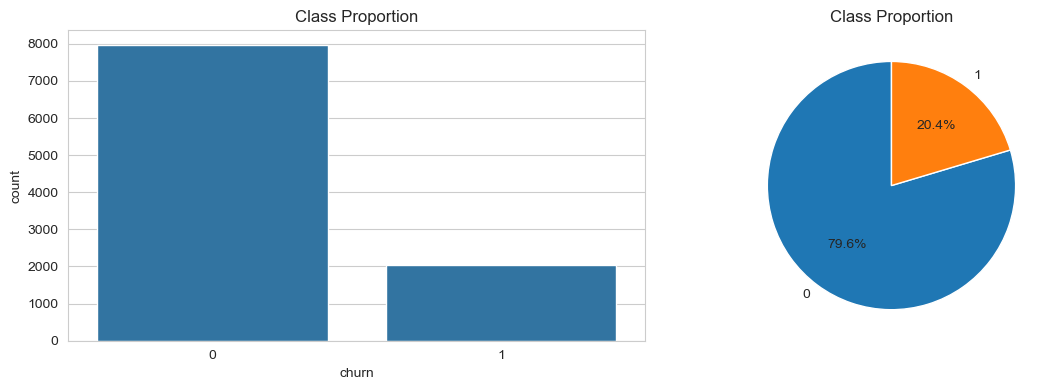

Class balance (%):
churn
0   79.63
1   20.37
Name: count, dtype: float64


In [55]:
fig, axes= plt.subplots(1, 2, figsize = (12, 4))

target_counts = df_clean["churn"].value_counts()

sns.countplot(x = "churn", data = df_clean, ax = axes[0])
axes[0].set_title("Class Proportion")

axes[1].pie(target_counts, labels=target_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Proportion")

plt.tight_layout()
savefig("01_target_class_balance.png")
plt.show()

print("Class balance (%):")
print((target_counts / len(df) * 100).round(2))

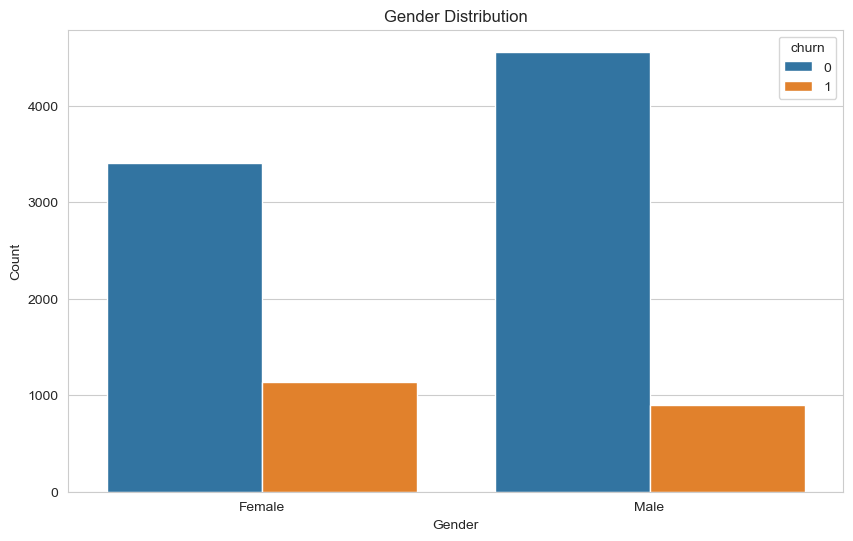

In [56]:
#gender vs customer churn
sns.countplot(x = "gender", data = df_clean, hue = "churn")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
fig.tight_layout()
savefig("02_churn_ditribution_by_gender.png")
plt.show()

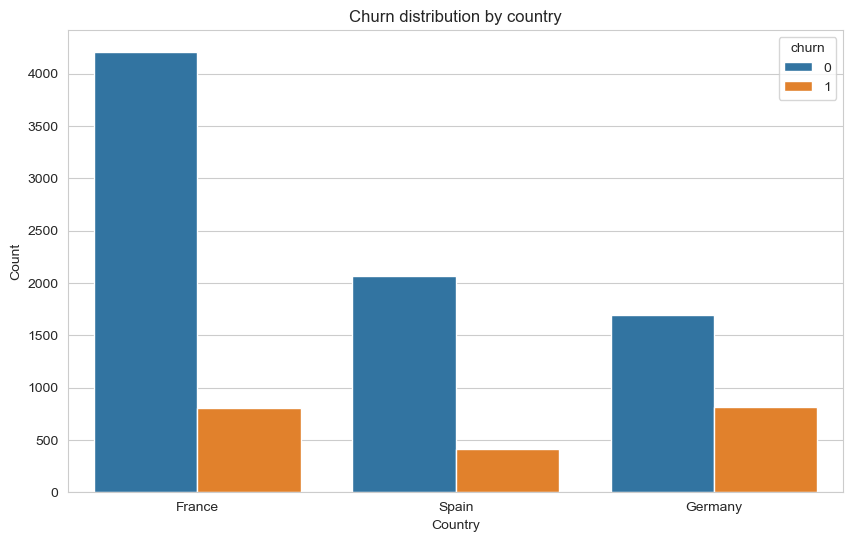

In [57]:
sns.countplot(x = "country", hue = "churn", data = df_clean)
plt.title("Churn distribution by country")
plt.xlabel("Country")
plt.ylabel("Count")
fig.tight_layout()
savefig("03_churn_distribution_by_country.png")
plt.show()

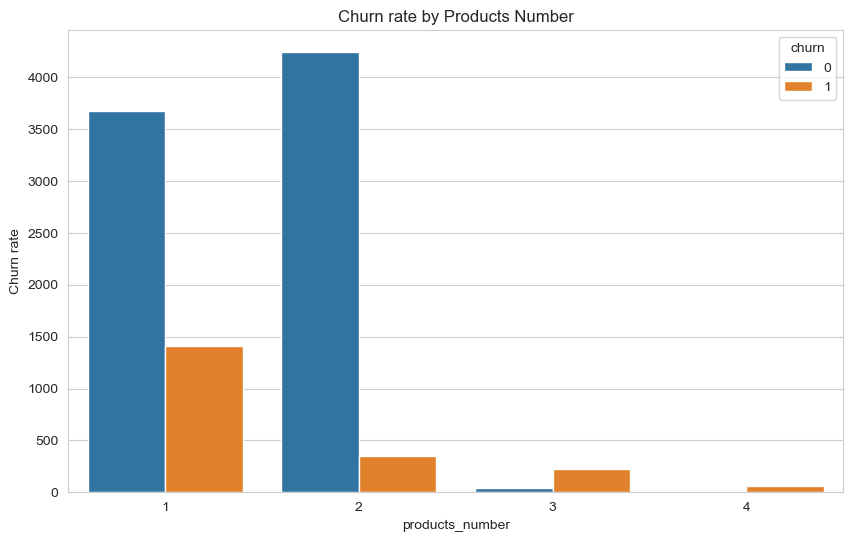

In [58]:
# products_number
sns.countplot(x = "products_number", hue = "churn", data = df_clean)
plt.title("Churn rate by Products Number")
plt.ylabel("Churn rate")
fig.tight_layout()
savefig("04_churn_distribution_by_prpduct_number.png")
plt.show()

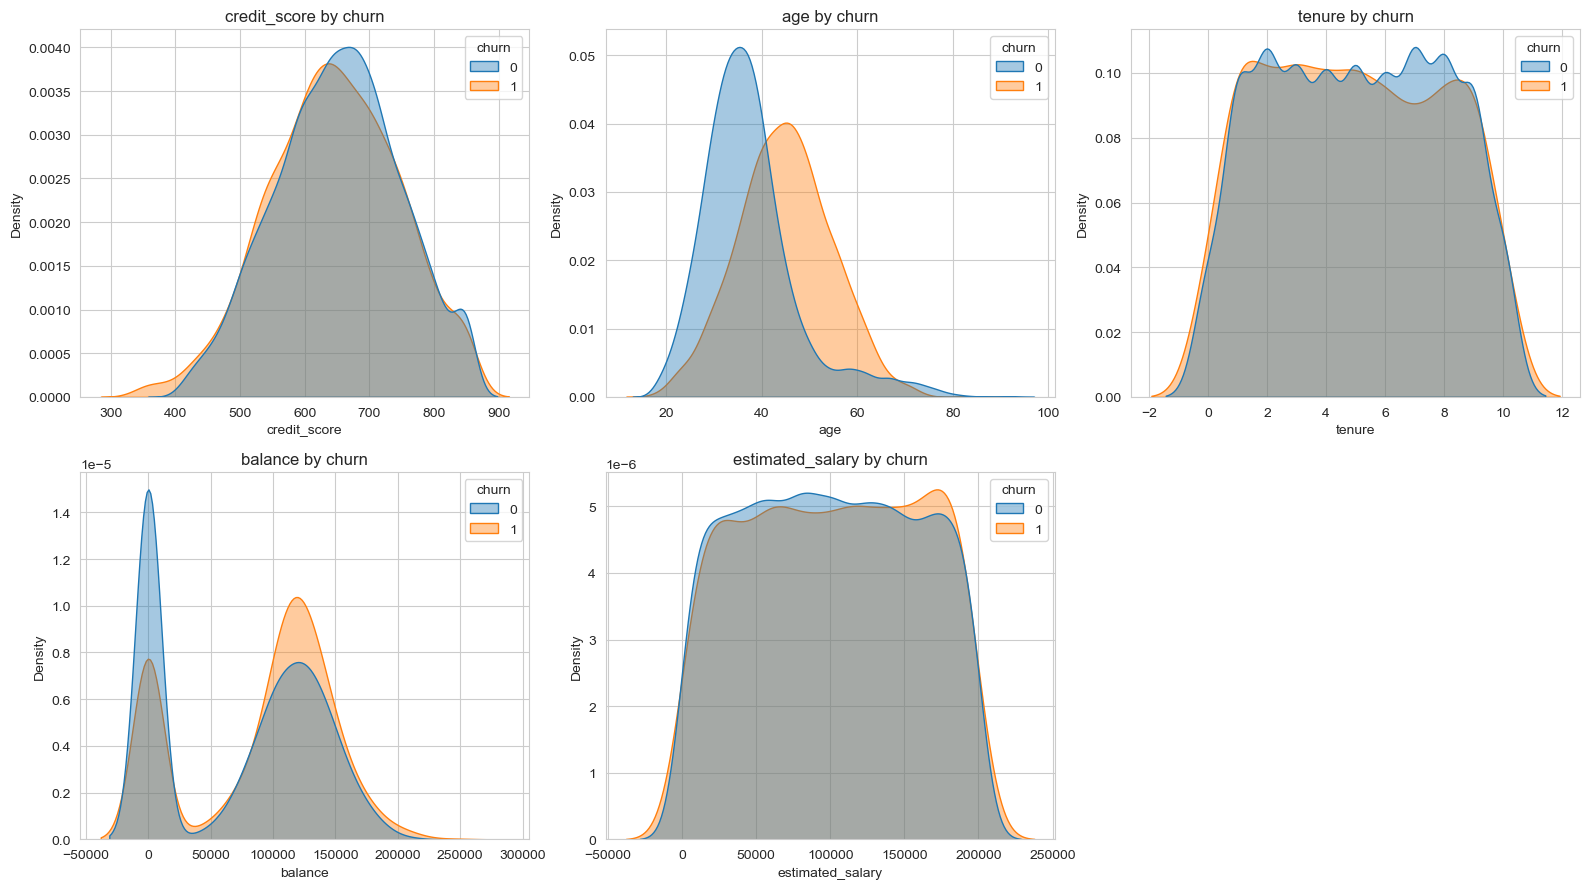

In [59]:
# Numeric feature distribution split by churn
numeric_cols = ["credit_score", "age", "tenure", "balance", "estimated_salary"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df_clean, x=col, hue="churn", fill=True, common_norm=False, ax=axes[i], alpha=0.4)
    axes[i].set_title(f"{col} by churn")
axes[-1].axis("off")
fig.tight_layout()
savefig("05_numeric_distribution_by_churn.png")
plt.show()

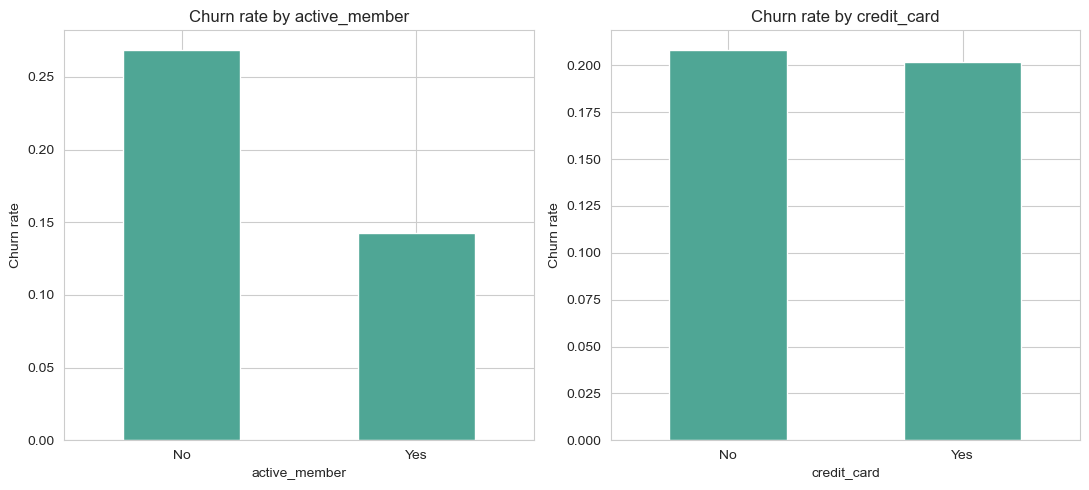

In [60]:
# Active member / credit card ownership vs churn
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, col in zip(axes, ["active_member","credit_card"]):
    churn_rate = df_clean.groupby(col)["churn"].mean()
    churn_rate.plot(kind="bar", ax=ax, color="#4FA695")
    ax.set_title(f"Churn rate by {col}")
    ax.set_xticklabels(["No", "Yes"], rotation=0)
    ax.set_ylabel("Churn rate")
fig.tight_layout()
savefig("06_churn_rate_active_creditcard.png")
plt.show()


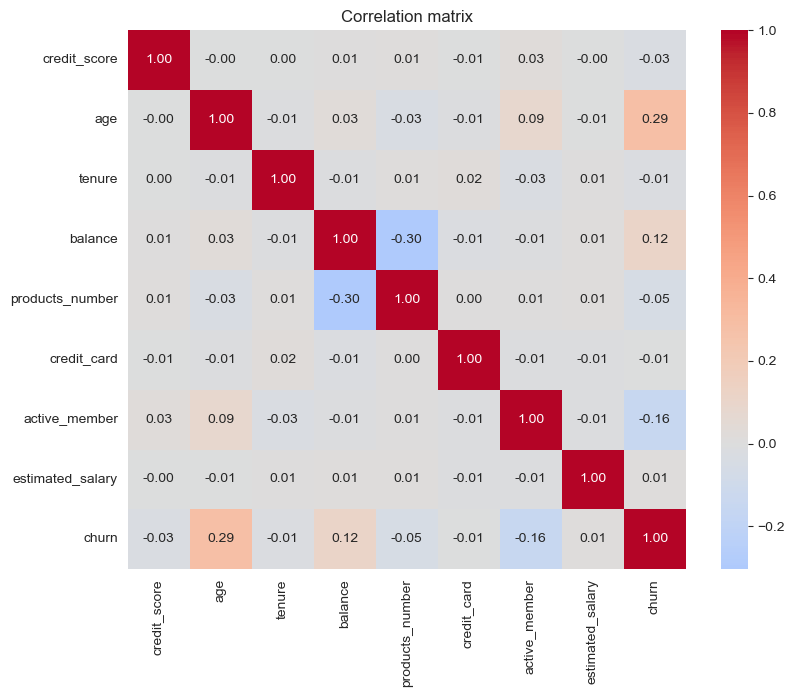

In [61]:
# Correlation heatmap (numeric feature only)
fig, ax = plt.subplots(figsize=(9, 7))
corr = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
savefig("07_correlation_heatmap.png")
plt.show()

#savefig("03_churn_rate_by_category.png")

**EDA keynote**
- The dataset is moderately imbalanced (~20% churn, ~80% retained).
- Churn rises sharply with **age** and is markedly higher for customers in
  **Germany** than France/Spain.
- Customers holding **more products but especially exactly 3–4 products**,
  and **inactive members**, churn far more often.
- `credit_card` ownership shows little difference in churn rate.
- No single numeric feature is strongly linearly correlated with churn —
  suggesting non-linear models (tree ensembles / neural nets) may add value
  over a purely linear model.


## **Feature Engineering**

In [18]:
fe = df_clean.copy()

# Balance relative to income - a customer with a huge balance vs low salary
# (or vice versa) may behave differently than raw balance alone suggests.
fe['balance_salary_ratio'] = fe['balance'] / (fe['estimated_salary'] + 1)

# Many customers carry a literal $0 balance (checking-only relationaship) -
# flag this distinct group explicitly rather than letting the raw 0 blend
# into the numeric distribution.
fe['zero_balance'] = (fe['balance'] == 0).astype(int)

# Multiple-product holders behave differently (EDA showed elevated churn
# for 3-4 products)
fe['has_multiple_products'] = (fe['products_number'] > 1).astype(int)

# Age buckets
fe['age_group'] = pd.cut(
    fe['age'], bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
).astype(str)

# Credit score buckets (industry-standard-ish bands)
fe['credit_score_category'] = pd.cut(
    fe['credit_score'], bins=[299, 579, 669, 739, 799, 850],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
).astype(str)

# Tenure buckets
fe['tenure_group'] = pd.cut(
    fe['tenure'], bins=[-1, 2, 6, 10],
    labels=['New', 'Mid', 'Long']
).astype(str)

print(f"Feature-engineered shape: {fe.shape}")
fe.head()


Feature-engineered shape: (10000, 17)


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,balance_salary_ratio,zero_balance,has_multiple_products,age_group,credit_score_category,tenure_group
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.00,1,0,41-50,Fair,New
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.74,0,0,41-50,Fair,New
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.40,0,1,41-50,Poor,Long
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.00,1,1,31-40,Good,New
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.59,0,0,41-50,Excellent,New


In [20]:
NUMERIC_FEATURES = [
    "credit_score", "age", "tenure", "balance", "products_number", "estimated_salary",
    "balance_salary_ratio", "zero_balance", "has_multiple_products", "credit_card",
    "active_member",
]

CATEGORICAL_FEATURES = [
    "country", "gender", "age_group", "credit_score_category", "tenure_group",
]

TARGET = "churn"
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical = {len(FEATURES)} features")
assert not fe[FEATURES + [TARGET]].isnull().any().any(), "Unexpected missing values after feature engineering"

11 numeric + 5 categorical = 16 features


In [21]:
fe.to_csv(CLEAN_DIR / "feature_engineering_data.csv", index=False )
print("Saved cleaned Feature Engineering data to", CLEAN_DIR / "cleaned_feature_engineering.csv")
print("Shape:", fe.shape)

Saved cleaned Feature Engineering data to C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\customer churn\clean_data\cleaned_feature_engineering.csv
Shape: (10000, 17)


## **Model Training**

#### **Train/Test split**

In [84]:
from sklearn.model_selection import train_test_split

X = fe[FEATURES].copy()
y = fe[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), " Test churn rate:", y_test.mean().round(3))


Train: (8000, 16)  Test: (2000, 16)
Train churn rate: 0.204  Test churn rate: 0.204


#### **Enconding and Scaling**

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

In [85]:
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), NUMERIC_FEATURES),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ]), CATEGORICAL_FEATURES),
    ])


## **Model Training**

Three Models:
- **Logistic Regression + Elastic Net**
- **XGBoost**
- **Nueral Network (MLP)**

In [86]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f"scale_pos_weight (XGBoost): {scale_pos_weight:.2f}")

models = {
    'LogisticRegression_ElasticNet': LogisticRegression(
        penalty='elasticnet', solver='saga', l1_ratio=0.5,
        C=1.0, max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight, eval_metric='logloss',
        random_state=RANDOM_STATE,
    ),
    'NeuralNetwork_MLP': MLPClassifier(
        hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
        alpha=1e-3, learning_rate_init=1e-3, max_iter=500,
        early_stopping=True, random_state=RANDOM_STATE,
    ),
}

trained_pipelines = {}
for name, clf in models.items():
    print(f"Training {name} ...")
    pipe = Pipeline([
        ('preprocessor', build_preprocessor()),
        ('classifier', clf),
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
print("All models trained.")


scale_pos_weight (XGBoost): 3.91
Training LogisticRegression_ElasticNet ...
Training XGBoost ...
Training NeuralNetwork_MLP ...
All models trained.


### **Model Evaluation**

In [71]:

def evaluate_model(model_name: str, model, X_test, y_test, reports_dir: Path) -> dict:
    """Compute metrics, save a confusion matrix + ROC curve PNG and a
    classification report TXT to `reports_dir`, and return a metrics dict."""
    reports_dir = Path(reports_dir)

    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:  # e.g. some SVMs without probability=True
        y_prob = model.decision_function(X_test)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"], ax=ax,
    )
    ax.set_title(f"{model_name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    savefig(REPORTS_DIR / f"confusion_matrix_{model_name}.png")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {metrics['roc_auc']:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name} - ROC Curve")
    ax.legend()
    savefig(REPORTS_DIR / f"roc_curve_{model_name}.png")

    with open(reports_dir / f"classification_report_{model_name}.txt", "w") as f:
        f.write(classification_report(y_test, y_pred, target_names=["Retained", "Churned"], zero_division=0))

    return metrics


In [87]:

results_rows = []
for name, pipe in trained_pipelines.items():
    metrics = evaluate_model(name, pipe, X_test, y_test, REPORTS_DIR)
    results_rows.append(metrics)
    print(f"{name:32s} " + " | ".join(f"{k}={v:.4f}" for k, v in metrics.items() if k != 'model'))

results_df = pd.DataFrame(results_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
results_df


LogisticRegression_ElasticNet    accuracy=0.7800 | precision=0.4741 | recall=0.7420 | f1_score=0.5785 | roc_auc=0.8487
XGBoost                          accuracy=0.8140 | precision=0.5320 | recall=0.7150 | f1_score=0.6101 | roc_auc=0.8601
NeuralNetwork_MLP                accuracy=0.8615 | precision=0.7902 | recall=0.4349 | f1_score=0.5610 | roc_auc=0.8574


,model,accuracy,precision,recall,f1_score,roc_auc
0,XGBoost,0.81,0.53,0.71,0.61,0.86
1,NeuralNetwork_MLP,0.86,0.79,0.43,0.56,0.86
2,LogisticRegression_ElasticNet,0.78,0.47,0.74,0.58,0.85


In [88]:
def plot_model_comparison(results_df: pd.DataFrame, reports_dir: Path) -> Path:
    comparison = results_df.set_index("model")
    fig, ax = plt.subplots(figsize=(12, 6))
    comparison[["accuracy", "precision", "recall", "f1_score", "roc_auc"]].plot(kind="bar", ax=ax)
    ax.set_title("Churn Model Comparison")
    ax.set_ylabel("Score")
    ax.set_xticklabels(comparison.index, rotation=0)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y")
    output_path = REPORTS_DIR / "model_comparison.png"
    savefig(output_path)
    return output_path


def save_model(model, name: str, models_dir: Path) -> Path:
    models_dir = Path(models_dir)
    models_dir.mkdir(parents=True, exist_ok=True)
    path = models_dir / f"{name}.pkl"
    joblib.dump(model, path)
    return path

In [89]:
comparison_path = plot_model_comparison(results_df, REPORTS_DIR)
print("Saved model comparison chart to", comparison_path)

model_report_path = REPORTS_DIR / "model_report.csv"
results_df.to_csv(model_report_path, index=False)
print("Saved model report to", model_report_path)

results_df.style.background_gradient(cmap='Greens', subset=['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'])


Saved model comparison chart to C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\customer churn\reports\model_comparison.png
Saved model report to C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\customer churn\reports\model_report.csv


,model,accuracy,precision,recall,f1_score,roc_auc
0,XGBoost,0.814000,0.531993,0.714988,0.610063,0.860117
1,NeuralNetwork_MLP,0.861500,0.790179,0.434889,0.561014,0.857435
2,LogisticRegression_ElasticNet,0.780000,0.474097,0.742015,0.578544,0.848676


In [90]:
best_model_name = results_df.iloc[0]['model']
best_pipeline = trained_pipelines[best_model_name]
print(f"Best model by ROC AUC: {best_model_name} (AUC = {results_df.iloc[0]['roc_auc']:.4f})")


Best model by ROC AUC: XGBoost (AUC = 0.8601)


### **Save Models**

In [91]:
import joblib

for name, pipe in trained_pipelines.items():
    save_model(pipe, name, MODELS_DIR)

# Convenience alias for "the model to use in production"
save_model(best_pipeline, "best_model", MODELS_DIR)
joblib.dump(FEATURES, MODELS_DIR / "feature_names.pkl")

print("Saved models to:", MODELS_DIR)
print(sorted(p.name for p in MODELS_DIR.glob('*.pkl')))


Saved models to: C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\customer churn\models
['LogisticRegression_ElasticNet.pkl', 'NeuralNetwork_MLP.pkl', 'XGBoost.pkl', 'best_model.pkl', 'feature_names.pkl']


## **Prediction Pipeline**

In [92]:
class ChurnPredictor:
    """Loads the saved best model and reproduces the Section 3 feature
    engineering for a single raw customer record (or a batch of records)."""

    def __init__(self, model_path=None):
        model_path = Path(model_path) if model_path else MODELS_DIR / "best_model.pkl"
        self.pipeline = joblib.load(model_path)
        self.feature_names = joblib.load(MODELS_DIR / "feature_names.pkl")

    @staticmethod
    def _engineer(raw: dict) -> dict:
        r = dict(raw)
        balance = float(r.get('balance', 0))
        salary = float(r.get('estimated_salary', 1))
        age = float(r.get('age', 30))
        credit_score = float(r.get('credit_score', 650))
        tenure = float(r.get('tenure', 0))
        products_number = float(r.get('products_number', 1))

        r['balance_salary_ratio'] = balance / (salary + 1)
        r['zero_balance'] = int(balance == 0)
        r['has_multiple_products'] = int(products_number > 1)

        r['age_group'] = pd.cut([age], bins=[17, 30, 40, 50, 60, 100],
                                 labels=['18-30', '31-40', '41-50', '51-60', '60+'])[0]
        r['credit_score_category'] = pd.cut([credit_score], bins=[299, 579, 669, 739, 799, 850],
                                             labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])[0]
        r['tenure_group'] = pd.cut([tenure], bins=[-1, 2, 6, 10],
                                    labels=['New', 'Mid', 'Long'])[0]
        return r

    def predict(self, raw: dict) -> dict:
        engineered = self._engineer(raw)
        X = pd.DataFrame([engineered])[self.feature_names]
        proba_churn = float(self.pipeline.predict_proba(X)[0, 1])
        return {
            'prediction': 'Churn' if proba_churn >= 0.5 else 'Retained',
            'probability_of_churn': round(proba_churn, 4),
            'probability_of_retention': round(1 - proba_churn, 4),
        }

    def predict_batch(self, raw_rows: list) -> list:
        return [self.predict(row) for row in raw_rows]


In [93]:
predictor = ChurnPredictor()

sample_customers = [
    {  # long-tenured, active, low balance -> expect low churn risk
        'credit_score': 720, 'country': 'France', 'gender': 'Male', 'age': 35,
        'tenure': 8, 'balance': 0, 'products_number': 1, 'credit_card': 1,
        'active_member': 1, 'estimated_salary': 60000,
    },
    {  # older, inactive, high balance, multiple products -> expect high churn risk
        'credit_score': 590, 'country': 'Germany', 'gender': 'Female', 'age': 58,
        'tenure': 2, 'balance': 150000, 'products_number': 3, 'credit_card': 1,
        'active_member': 0, 'estimated_salary': 45000,
    },
]

for i, cust in enumerate(sample_customers, start=1):
    print(f"Customer {i}: {predictor.predict(cust)}")


Customer 1: {'prediction': 'Retained', 'probability_of_churn': 0.2936, 'probability_of_retention': 0.7064}
Customer 2: {'prediction': 'Churn', 'probability_of_churn': 0.9956, 'probability_of_retention': 0.0044}


In [94]:
# Batch-score the held-out test set and save predictions for review
test_records = X_test.copy()
test_records['actual_churn'] = y_test.values
test_records['predicted_churn'] = best_pipeline.predict(X_test)
test_records['probability_of_churn'] = best_pipeline.predict_proba(X_test)[:, 1]

predictions_path = REPORTS_DIR / "test_set_predictions.csv"
test_records.to_csv(predictions_path, index=False)
print("Saved test-set predictions to", predictions_path)
test_records.head()


Saved test-set predictions to C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\customer churn\reports\test_set_predictions.csv


,credit_score,age,tenure,balance,products_number,estimated_salary,balance_salary_ratio,zero_balance,has_multiple_products,credit_card,active_member,country,gender,age_group,credit_score_category,tenure_group,actual_churn,predicted_churn,probability_of_churn
5702,585,36,7,0.00,2,94283.09,0.00,1,1,1,0,France,Male,31-40,Fair,Long,0,0,0.04
3667,525,33,4,131023.76,2,55072.93,2.38,0,1,0,0,Germany,Male,31-40,Poor,Mid,0,0,0.19
1617,557,40,4,0.00,2,105433.53,0.00,1,1,0,1,Spain,Female,31-40,Poor,Mid,0,0,0.09
5673,639,34,5,139393.19,2,33950.08,4.11,0,1,0,0,Spain,Male,31-40,Fair,Mid,0,0,0.10
4272,640,34,3,77826.80,1,168544.85,0.46,0,0,1,1,Spain,Female,31-40,Fair,Mid,0,0,0.22
